Run block by block

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(302)

# 1. Polynomial feature generator
def make_polynomial_features(x, degree):
    return np.hstack([x**i for i in range(degree + 1)])   ## Note: X = [1, x, x**2, x**3, ..., x**degree]

# 2. Model fitting: w = (X^T X)^(-1) X^T y
def fit_linear_regression(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y   ## Note: pinv = pseudo-inverse

def predict(X, w):  # Predict
    return X @ w

def mean_squared_error(y_true, y_pred):  # MSE
    return np.mean((y_true - y_pred) ** 2)

# 3. K-fold CV
def k_fold_split(n_samples, k=5, shuffle=True):
    indices = np.arange(n_samples)  ## Note: index array
    if shuffle:
        np.random.shuffle(indices)

    # K-fold
    folds = np.array_split(indices, k)
    splits = []

    for i in range(k):
        val_idx = folds[i]   ## Note: Validation set

        train_idx = np.hstack([folds[j] for j in range(k) if j != i])   ## Note: Training set
        splits.append((train_idx, val_idx))

    return splits

In [17]:
# Training set
n_samples = 30
x_train = np.sort(np.random.rand(n_samples, 1) * 4, axis=0)
y_train = np.sin(x_train).ravel() + np.random.normal(0, 0.25, n_samples)

# Testing set
x_test = np.linspace(0, 4, 200)[:, np.newaxis]
y_test = np.sin(x_test).ravel()

# Overfitting
DEGREE_OVERFIT = 9    #% Settings
X_train_poly = make_polynomial_features(x_train, DEGREE_OVERFIT)
X_test_poly = make_polynomial_features(x_test, DEGREE_OVERFIT)

# Train
w_overfit = fit_linear_regression(X_train_poly, y_train)

# MSE
train_err = mean_squared_error(y_train, predict(X_train_poly, w_overfit))
test_err = mean_squared_error(y_test, predict(X_test_poly, w_overfit))

print(f"--- Degree: {DEGREE_OVERFIT} ---")
print(f"Train MSE: {train_err:.4f}")
print(f"Test MSE : {test_err:.4f}")

--- Degree: 9 ---
Train MSE: 0.0424
Test MSE : 0.8992


In [18]:
# K-fold Cross-Validation
k = 4     #% Settings
splits = k_fold_split(n_samples, k=k, shuffle=True)

candidate_degrees = list(range(1, n_samples - 1))
cv_errors = []

for deg in candidate_degrees:
    fold_errors = []

    for train_idx, val_idx in splits:
        # Train valid split
        x_tr_fold, y_tr_fold = x_train[train_idx], y_train[train_idx]
        x_val_fold, y_val_fold = x_train[val_idx], y_train[val_idx]

        X_tr_fold = make_polynomial_features(x_tr_fold, deg)
        X_val_fold = make_polynomial_features(x_val_fold, deg)

        # Train and validate
        w_fold = fit_linear_regression(X_tr_fold, y_tr_fold)
        val_pred = predict(X_val_fold, w_fold)

        fold_errors.append(mean_squared_error(y_val_fold, val_pred))

    cv_errors.append(np.mean(fold_errors)) ## Note: Kfold mean validation error

# Find best degree (smallest CV error)
best_degree = candidate_degrees[np.argmin(cv_errors)]
print(f"\nBest degree: {best_degree}")

# Re-Training
X_train_best = make_polynomial_features(x_train, best_degree)
X_test_best = make_polynomial_features(x_test, best_degree)

w_fixed = fit_linear_regression(X_train_best, y_train)
fixed_test_err = mean_squared_error(y_test, predict(X_test_best, w_fixed))

print(f"MSE (Degree = {best_degree}): {fixed_test_err:.4f}")


Best degree: 2
MSE (Degree = 2): 0.0269


Visualization & Predicting

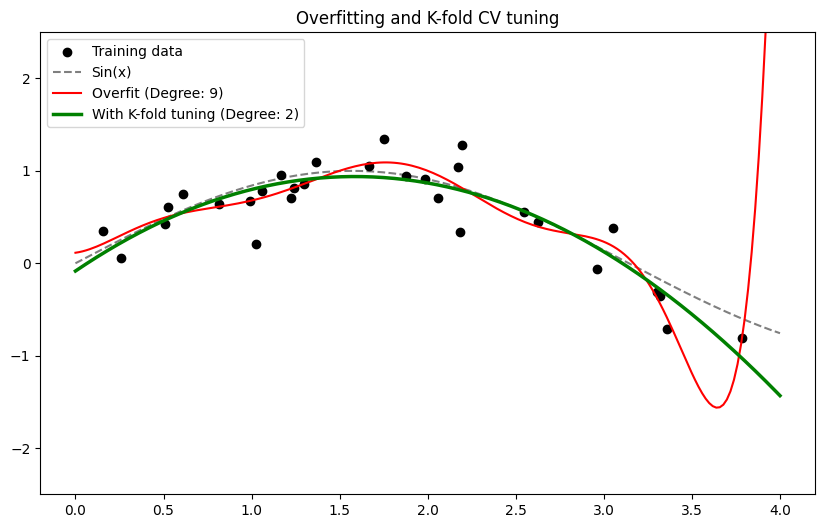

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='black', label='Training data')
plt.plot(x_test, y_test, 'k--', alpha=0.5, label='Sin(x)')

# Overfit model
plt.plot(x_test, predict(X_test_poly, w_overfit), color='red',
         label=f'Overfit (Degree: {DEGREE_OVERFIT})')

# Fixed model
plt.plot(x_test, predict(X_test_best, w_fixed), color='green', linewidth=2.5,
         label=f'With K-fold tuning (Degree: {best_degree})')

plt.ylim(-2.5, 2.5)
plt.legend()
plt.title("Overfitting and K-fold CV tuning")
plt.show()

In [10]:
# Prediction test
a = float(input("Input x: "));

x_new = np.array([[a]])
X_new_poly_1 = make_polynomial_features(x_new, degree=best_degree)
X_new_poly_2 = make_polynomial_features(x_new, degree=DEGREE_OVERFIT)

# y(s)
y_pred = predict(X_new_poly_1, w_fixed)
y_overfit_pred = predict(X_new_poly_2, w_overfit)
y_real = np.sin(a)

print(f"Predicted value from the overfit model at x = {a}: {y_overfit_pred[0]:.4f}  [{(y_overfit_pred[0] - y_real):.4f}]")
print(f"Predicted value from the fixed model at x = {a}: {y_pred[0]:.4f}  [{(y_pred[0] - y_real):.4f}]")
print(f"Expected value at x = {a}: {y_real:.4f}")

Input x: 3.0
Predicted value from the overfit model at x = 3.0: 0.7102  [0.5691]
Predicted value from the fixed model at x = 3.0: 0.0360  [-0.1051]
Expected value at x = 3.0: 0.1411
